In [1]:
import pandas as pd

# Crear datos manualmente
data = {
    "Order Date": ["2025-01-05", "2025-01-07", "2025-01-10"],
    "Product": ["Laptop", "Mouse", "Desk"],
    "Sales": [3500, 80, 500],
    "Quantity": [1, 2, 1]
}

df = pd.DataFrame(data)

print(df)

   Order Date Product  Sales  Quantity
0  2025-01-05  Laptop   3500         1
1  2025-01-07   Mouse     80         2
2  2025-01-10    Desk    500         1


In [2]:
import pandas as pd

data = {
    "Order Date": ["2025-01-05", "2025-01-07", "2025-01-10", "2025-02-03", "2025-02-05", "2025-02-10"],
    "Product": ["Laptop", "Mouse", "Desk", "Chair", "Notebook", "Printer"],
    "Category": ["Technology", "Technology", "Furniture", "Furniture", "Office Supplies", "Technology"],
    "Sales": [3500, 80, 500, 300, 20, 900],
    "Quantity": [1, 2, 1, 1, 5, 1],
    "Region": ["Lima", "Arequipa", "Lima", "Cusco", "Lima", "Piura"]
}

df = pd.DataFrame(data)

# Guardar como CSV
df.to_csv("ventas.csv", index=False)

print("Archivo creado")

Archivo creado


In [3]:
df = pd.read_csv("ventas.csv")

print(df)

   Order Date   Product         Category  Sales  Quantity    Region
0  2025-01-05    Laptop       Technology   3500         1      Lima
1  2025-01-07     Mouse       Technology     80         2  Arequipa
2  2025-01-10      Desk        Furniture    500         1      Lima
3  2025-02-03     Chair        Furniture    300         1     Cusco
4  2025-02-05  Notebook  Office Supplies     20         5      Lima
5  2025-02-10   Printer       Technology    900         1     Piura


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  6 non-null      datetime64[ns]
 1   Product     6 non-null      object        
 2   Category    6 non-null      object        
 3   Sales       6 non-null      int64         
 4   Quantity    6 non-null      int64         
 5   Region      6 non-null      object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 420.0+ bytes
None


In [5]:
print("Ventas totales:", df["Sales"].sum())

Ventas totales: 5300


In [6]:
print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False))

Product
Laptop      3500
Printer      900
Desk         500
Chair        300
Mouse         80
Notebook      20
Name: Sales, dtype: int64


In [7]:
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

Category
Technology         4480
Furniture           800
Office Supplies      20
Name: Sales, dtype: int64


In [8]:
df["Month"] = df["Order Date"].dt.to_period("M")

ventas_mes = df.groupby("Month")["Sales"].sum()

print(ventas_mes)

Month
2025-01    4080
2025-02    1220
Freq: M, Name: Sales, dtype: int64


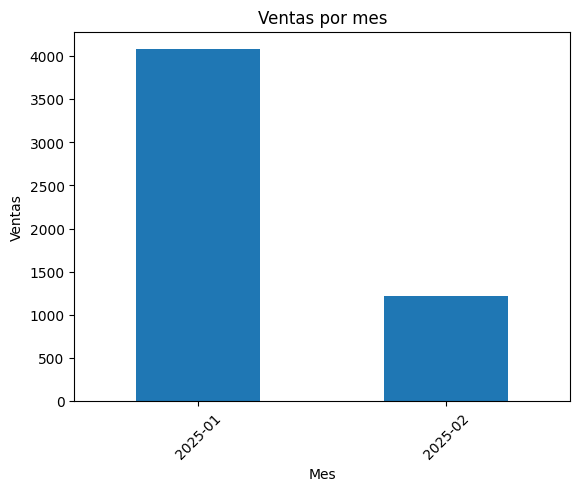

In [9]:
import matplotlib.pyplot as plt

ventas_mes.plot(kind="bar")

plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(rotation=45)

plt.show()

In [10]:
top_productos = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(3)
print("Top 3 productos más vendidos:")
print(top_productos)

Top 3 productos más vendidos:
Product
Notebook    5
Mouse       2
Desk        1
Name: Quantity, dtype: int64


In [11]:
ventas_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("\nVentas por región:")
print(ventas_region)


Ventas por región:
Region
Lima        4020
Piura        900
Cusco        300
Arequipa      80
Name: Sales, dtype: int64


In [12]:
ticket_promedio = df["Sales"].mean()
print("\nTicket promedio:", ticket_promedio)


Ticket promedio: 883.3333333333334


In [13]:
with pd.ExcelWriter("reporte_ventas.xlsx") as writer:
    df.to_excel(writer, sheet_name="Datos", index=False)
    ventas_mes.to_excel(writer, sheet_name="Ventas por mes")
    ventas_region.to_excel(writer, sheet_name="Ventas por region")

print("Reporte exportado a Excel")

Reporte exportado a Excel


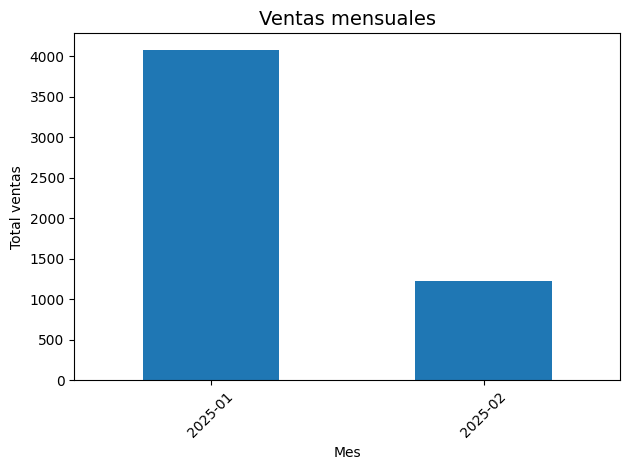

In [14]:
ventas_mes.plot(kind="bar")

plt.title("Ventas mensuales", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Total ventas")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()